In [2]:
!uv pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 43.5/235.7 GB disk)


(121, 121, 3)
(124, 115, 3)


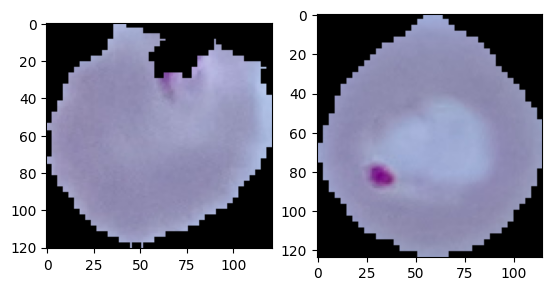

In [3]:
import cv2
import matplotlib.pyplot as plt

# !ls drive/MyDrive/datasets/cell_images_truncated/maleria/train/Parasitized/

import os
import numpy as np
imgDir = 'drive/MyDrive/datasets/cell_images_truncated/maleria/train/Parasitized/'


imgList = []
for fileName in os.listdir(imgDir):
    imgList.append(fileName)


imgPath = imgDir+imgList[0]
img1 = cv2.imread(imgPath)
imgPath = imgDir+imgList[1]
img2 = cv2.imread(imgPath)

print(img1.shape)
print(img2.shape)

# img2 = cv2.resize(img2, (121,121))
# img = np.hstack([img1, img2])
plt.subplot(1,2,1)
plt.imshow(img1)

plt.subplot(1,2,2)
plt.imshow(img2)
plt.show()

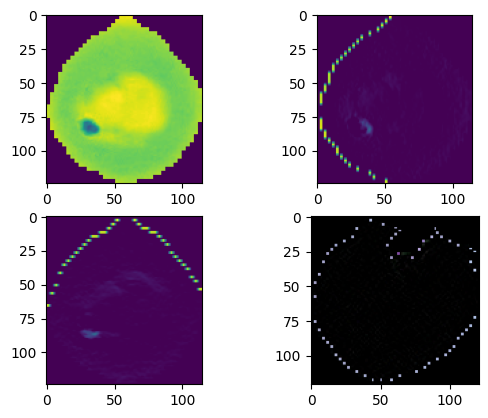

In [4]:
grayImg = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
# plt.imshow(grayImg)
# plt.show()

sobelX = cv2.Sobel(grayImg, cv2.CV_16UC1, 1, 0, ksize = 3)
# plt.imshow(sobelX)
# plt.show()

sobelY = cv2.Sobel(grayImg, cv2.CV_16U, 0, 1, ksize = 3)


sobelXY = cv2.Sobel (img1, cv2.CV_16U, 1, 1, ksize = 3)


plt.subplot(2, 2, 1)
plt.imshow(grayImg)

plt.subplot(2, 2, 2)
plt.imshow(sobelX)

plt.subplot(2, 2, 3)
plt.imshow(sobelY)

plt.subplot(2, 2, 4)
plt.imshow(sobelXY)

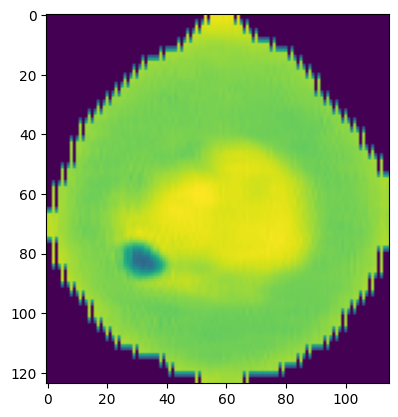

In [5]:
grayImg = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)


kernel = np.array([[1, 1, 1],[-1, -1, -1],[1, 1, 1]], dtype = np.float32)
imgFiltered = cv2.filter2D(grayImg, cv2.CV_16U, kernel = kernel)
imgFiltered2 = cv2.filter2D(grayImg, cv2.CV_16U, kernel = kernel.transpose())

plt.imshow(imgFiltered2)
plt.show()

(213, 320, 3)


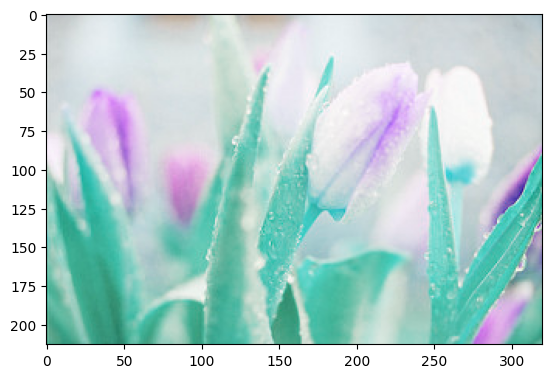

In [6]:
# !ls drive/MyDrive/datasets/flower_photos/tulips
imgDir = 'drive/MyDrive/datasets/flower_photos/tulips/'
imgName = '10094729603_eeca3f2cb6.jpg '

imgList = []
for fileName in os.listdir(imgDir):
    imgList.append(fileName)
    # print(fileName)


# print(imgList[0])
img = cv2.imread(imgDir+imgList[2])
print(img.shape)
plt.imshow(img)
plt.show()


image 1/1 /content/drive/MyDrive/datasets/flower_photos/tulips/14014595475_5892fcda51_n.jpg: 448x640 1 potted plant, 1 vase, 103.5ms
Speed: 6.3ms preprocess, 103.5ms inference, 32.5ms postprocess per image at shape (1, 3, 448, 640)


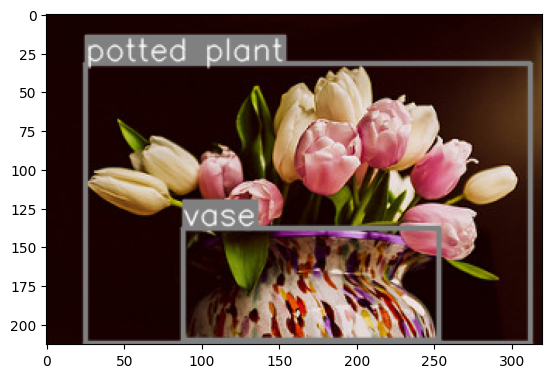

In [7]:
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator

model = YOLO('yolov8n.pt')
imgNum = 22
img = cv2.imread(imgDir+imgList[imgNum])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = model.predict(imgDir+imgList[imgNum])


for i in results:
    annotator = Annotator(img)
    for box in i.boxes:
        b = box.xyxy[0]
        c = box.cls
        annotator.box_label(b, model.names[int(c)])

plt.imshow(annotator.result())
plt.show()

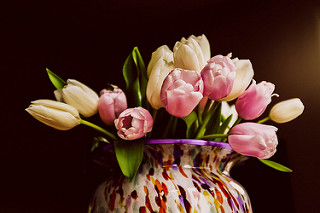

In [8]:
from IPython.display import display, Image
imgNum = 22
Image(imgDir+imgList[imgNum])

In [9]:
# dataPath = 'drive/MyDrive/datasets/taco'

!ls drive/MyDrive/datasets/taco

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [10]:
!nano drive/MyDrive/datasets/taco/data.yaml

/bin/bash: line 1: nano: command not found


In [11]:
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator

yamlFilePath = '/content/drive/MyDrive/datasets/taco/data.yaml'
# !cat yoloData.yaml
model = YOLO('yolov8n.pt')
results = model.train(data=yamlFilePath, epochs=100, imgsz = 416, device = 0)
!cd drive/MyDrive/datasets/taco/


Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/datasets/taco/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

KeyboardInterrupt: 

In [13]:
# import os
src = 'train4.zip'
dest = 'drive/MyDrive/ml_train/yolo'

# !ls runs/detect
# !ls drive/MyDrive/ml_train

!cp "{src}" "{dest}"
# !zip -r train4.zip runs/detect/train4/

cp: cannot stat 'train4.zip': No such file or directory


In [14]:
import os

testDataPath = 'drive/MyDrive/datasets/taco/test/images/'
imageNames = []
for img in os.listdir(testDataPath):
    imageNames.append(img)

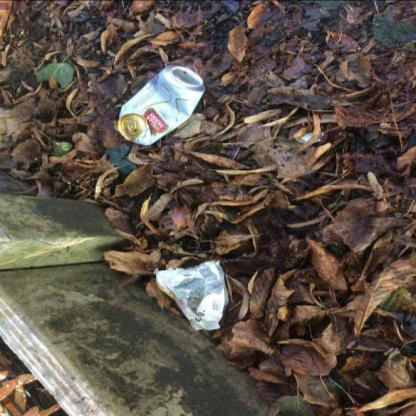

In [15]:
from IPython.display import display, Image
num = 30
imagePath = testDataPath+imageNames[num]
Image(imagePath)


image 1/1 /content/drive/MyDrive/datasets/taco/test/images/000004_JPG_jpg.rf.ba02873bf0c7600d314dfd42a5617b8d.jpg: 416x416 1 Can, 1 Plastic bag - wrapper, 6.8ms
Speed: 1.0ms preprocess, 6.8ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 416)


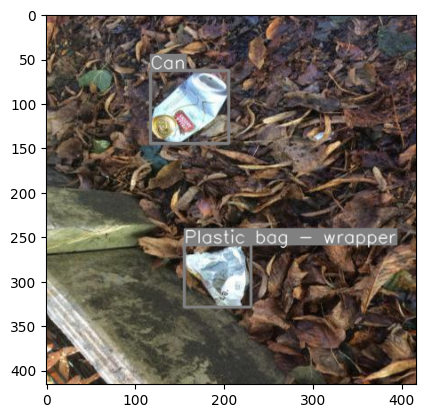

In [17]:
from ultralytics.utils.plotting import Annotator
import cv2
import matplotlib.pyplot as plt
model = YOLO('runs/detect/train/weights/best.pt')

img = cv2.imread(imagePath)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

result = model(imagePath)


for r in result:
    annotator = Annotator(img)
    for box in r.boxes:
        b = box.xyxy[0]
        c = box.cls
        annotator.box_label(b,model.names[int(c)])

plt.imshow(annotator.result())
plt.show()

In [18]:
!pip install onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 133.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 126.7 MB/s eta 0:00:00


In [19]:
modelPath = "/content/drive/MyDrive/ml_train/yolo_1/best.pt"
model = YOLO(modelPath)

In [20]:
model.export(format = "onnx", dynamic=True, opset=17, nms=True)

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
WARNING ⚠️ 'dynamic=True' model with 'nms=True' requires max batch size, i.e. 'batch=16'
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,009,158 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/ml_train/yolo_1/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 300, 6) (5.9 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 308ms
Prepared 3 packages in 2.41s
Installed 3 packages in 62ms
 + colorama==0.4.6
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: start

'/content/drive/MyDrive/ml_train/yolo_1/best.onnx'